<a href="https://colab.research.google.com/github/unidari/ml/blob/main/ml_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [1387]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [1388]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=20)
X_train.shape, X_test.shape

((130, 4), (20, 4))

#### 1.2. Обучите модель KNN

In [1389]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=4)
model.fit(X_train, y_train)
X_train.shape, X_test.shape

((130, 4), (20, 4))

#### 1.3. Проверьте качество работы модели

In [1390]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
print(pred_test, y_test)
print(accuracy_score(y_test, pred_test))

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2] [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2]
1.0


#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [1391]:
acc_scores = []

for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc_score = accuracy_score(y_test, model.predict(X_test))
    acc_scores.append(acc_score)

df = pd.DataFrame({'k': [i for i in range(1, 11)], 'Accuracy Scores': acc_scores})
df

,k,Accuracy Scores
0,1,1.00
1,2,1.00
2,3,1.00
3,4,1.00
4,5,1.00
5,6,1.00
6,7,0.95
7,8,1.00
8,9,1.00
9,10,1.00


### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [1392]:
test_index = [5, 8]
test_samples = X_test.iloc[test_index]
test_samples

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
31,5.4,3.4,1.5,0.4
68,6.2,2.2,4.5,1.5


#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [1393]:
import numpy as np

dist = pd.DataFrame()
dist['trained'] = y_train

for i, idx in enumerate(test_index):
    samp = test_samples.iloc[i].values
    distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
    dist[f'distance to test sample {idx}'] = distto

display(dist)

,trained,distance to test sample 5,distance to test sample 8
0,0,0.761577,3.653765
1,2,3.764306,0.948683
2,0,0.412311,3.535534
3,2,4.589118,1.403567
4,2,5.742822,3.051229
...,...,...,...
125,1,2.812472,0.812404
126,2,3.427827,1.349074
127,0,0.806226,3.997499
128,1,2.773085,0.812404


#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [1394]:
k = 5
top5 = dist.sort_values('distance to test sample 5', ascending=True).head(k)
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k)
display(top5)
display(top8)

,trained,distance to test sample 5,distance to test sample 8
124,0,0.282843,3.407345
17,0,0.300000,3.657868
36,0,0.300000,3.706751
81,0,0.346410,3.734970
24,0,0.360555,3.685105


,trained,distance to test sample 5,distance to test sample 8
120,1,3.352611,0.264575
83,1,3.793415,0.509902
78,2,3.906405,0.538516
90,1,3.519943,0.678233
15,2,4.014972,0.714143


#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [1395]:
pred5 = top5['trained'].value_counts().index[0]
pred8 = top8['trained'].value_counts().index[0]
print(f'predict to test sample 5 - {pred5}')
print(f'predict to test sample 8 - {pred8}')

predict to test sample 5 - 0
predict to test sample 8 - 1


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [1396]:
print(f"{y_test[test_index[0]]}")
print(f"{y_test[test_index[1]]}")

0
1


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [1397]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [1398]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=20)
X_train.shape, X_test.shape

((20620, 8), (20, 8))

Затем нормализуйте данные:

In [1399]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [1400]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=20)
model.fit(X_train, y_train)
X_train.shape, X_test.shape

((20620, 8), (20, 8))

#### 3.3. Проверьте качество работы модели

In [1401]:
from sklearn.metrics import r2_score

pred_test = model.predict(X_test)
print(r2_score(y_test, pred_test))

0.8056508282838839


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

,k,R2 score
0,1,0.858716
1,2,0.723495
2,3,0.697761
3,4,0.744187
4,5,0.721665
5,6,0.741955
6,7,0.726549
7,8,0.745171
8,9,0.765713
9,10,0.787990


<Axes: xlabel='k'>

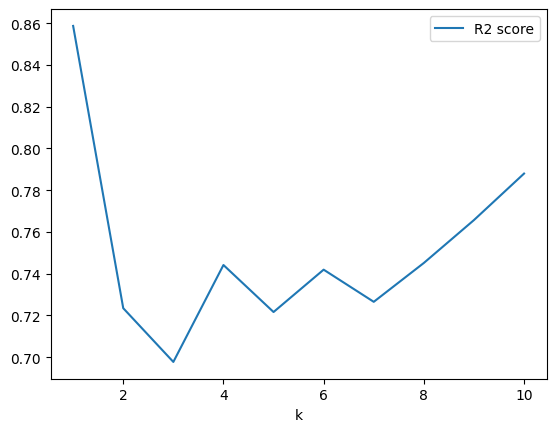

In [1402]:
metrics_scores = []

for k in range(1, 11):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    score = r2_score(y_test, model.predict(X_test))
    metrics_scores.append(score)

df = pd.DataFrame({'k': [i for i in range(1, 11)], 'R2 score': metrics_scores})
display(df)

df.plot(x='k', y='R2 score')

### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [1403]:
test_indices = [5, 8]
test_samples = X_test.iloc[test_indices]
test_samples

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5,0.290672,0.215686,0.031230,0.019024,0.067182,0.001734,0.163656,0.671315
8,0.296803,0.058824,0.021824,0.020829,0.029345,0.000890,0.515409,0.226096


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [1404]:
import numpy as np

dist = pd.DataFrame()
dist['trained'] = y_train

for i, idx in enumerate(test_index):
    samp = test_samples.iloc[i].values
    distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
    dist[f'distance to test sample {idx}'] = distto

display(dist)


,trained,distance to test sample 5,distance to test sample 8
0,4.25000,0.897833,0.844395
1,4.05600,0.750188,1.037071
2,1.38800,0.371820,0.258473
3,5.00001,0.727629,0.558573
4,1.62100,0.159154,0.726330
...,...,...,...
20615,2.29200,0.470182,0.834919
20616,0.97800,0.428520,0.825591
20617,2.22100,0.492802,0.820984
20618,2.83500,0.578533,0.227557


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [1405]:
k = 5
top5 = dist.sort_values('distance to test sample 5', ascending=True).head(k)
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k)
display(top5)
display(top8)


,trained,distance to test sample 5,distance to test sample 8
8018,1.440,0.032895,0.583450
3518,1.845,0.041233,0.566741
3546,1.370,0.043973,0.584839
1583,2.679,0.049581,0.619352
1563,1.908,0.050657,0.593988


,trained,distance to test sample 5,distance to test sample 8
9609,2.655,0.580758,0.027404
16771,1.848,0.559495,0.039728
6321,2.464,0.570492,0.041293
10359,1.604,0.565096,0.044181
19757,1.590,0.556387,0.044326


#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [1406]:
pred5 = top5['trained'].mean()
pred8 = top8['trained'].mean()
print(f'predict to test sample 5 - {pred5}')
print(f'predict to test sample 8 - {pred8}')


predict to test sample 5 - 1.8483999999999998
predict to test sample 8 - 2.0322000000000005


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [1407]:
print(f"{y_test[test_index[0]]}")
print(f"{y_test[test_index[1]]}")


1.587
3.4


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [1408]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [1409]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [1410]:
sepal_petal = X[['sepal length (cm)', 'petal width (cm)']]
sepal_petal


,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2
...,...,...
145,6.7,2.3
146,6.3,1.9
147,6.5,2.0
148,6.2,2.3


### Визуализируйте ваши данные на графике

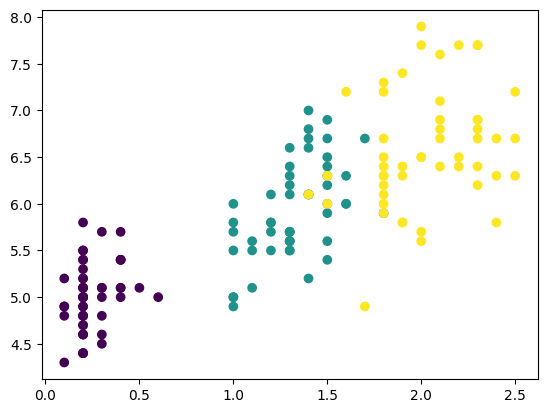

In [1411]:
import matplotlib.pyplot as plt

plt.scatter(sepal_petal['petal width (cm)'], sepal_petal['sepal length (cm)'], c=y)

plt.show()

### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [1412]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(sepal_petal, y, random_state=42, test_size=20)
X_train.shape, X_test.shape


((130, 2), (20, 2))

#### 1.2. Обучите модель KNN на 50 соседях

In [1413]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors)
model.fit(X_train, y_train)
X_train.shape, X_test.shape

((130, 2), (20, 2))

#### 1.3. Проверьте качество работы модели

In [1414]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
print(pred_test, y_test)
print(accuracy_score(y_test, pred_test))

[1 0 2 1 2 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2] [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2]
0.95


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [1415]:
import numpy as np
test_index = [8]
test_samples = X_test.iloc[test_index]

dist = pd.DataFrame()
dist['trained'] = y_train

samp = test_samples.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist[f'distance to test sample 8'] = distto

display(dist)

,trained,distance to test sample 8
0,0,1.984943
1,2,0.316228
2,0,1.627882
3,2,0.632456
4,2,1.772005
...,...,...
125,1,0.223607
126,2,1.315295
127,0,1.360147
128,1,0.500000


#### 1.5. Выберите топ  k  соседей


In [1416]:
k = 15
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k)
display(top8)


,trained,distance to test sample 8
26,2,0.100000
83,1,0.100000
73,2,0.141421
89,1,0.141421
100,1,0.141421
49,1,0.200000
16,1,0.200000
78,2,0.200000
120,1,0.223607
72,1,0.223607


#### 1.6. Выведите финальное предсказание для этого объекта

In [1417]:
pred8 = top8['trained'].value_counts().index[0]
print(f'predict to test sample 8 - {pred8}')


predict to test sample 8 - 1


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [1418]:
print(f"Настоящее целевое значение: {y_test[test_index]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[test_index]}")

Настоящее целевое значение: [1]
Предсказанное целевое значение для объекта: [1]


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

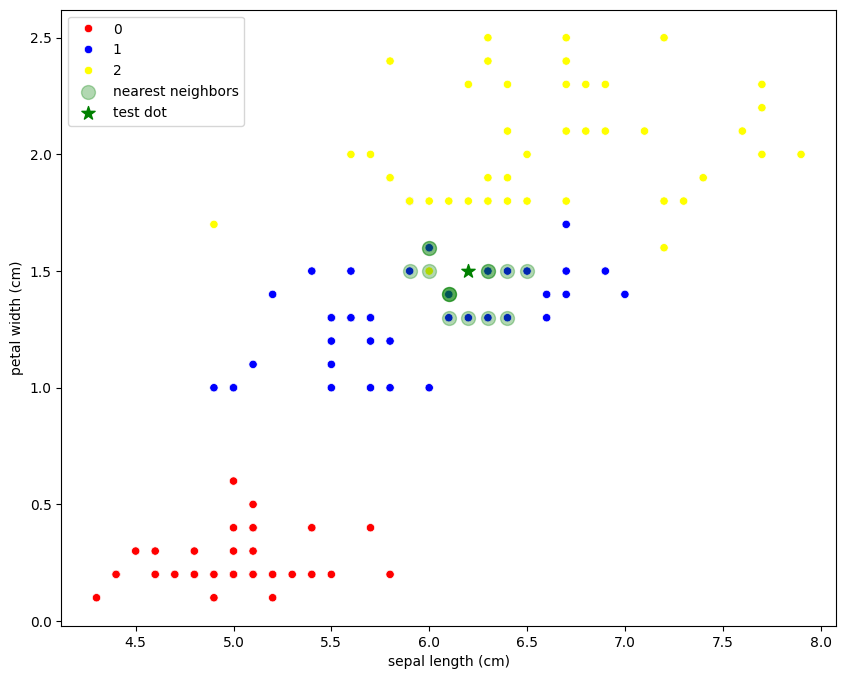

In [1419]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_bold = ['red', 'blue', 'yellow']

nearest_index = dist.sort_values('distance to test sample 8').head(k).index
plt.figure(figsize=(10, 8))
#обучающие данные
sns.scatterplot(
    x=X_train['sepal length (cm)'],
    y=X_train['petal width (cm)'],
    hue=y_train,
    palette=cmap_bold
)
#соседи
plt.scatter(
    X_train.iloc[nearest_index]['sepal length (cm)'],
    X_train.iloc[nearest_index]['petal width (cm)'],
    c='g',
    alpha = 0.3,
    marker='o',
    s=100,
    label='nearest neighbors'
)
#тестовая точка
plt.scatter(
    X_test.iloc[test_index]['sepal length (cm)'],
    X_test.iloc[test_index]['petal width (cm)'],
    c='g',
    marker='*',
    s=100,
    label='test dot'
)


plt.legend()

### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [1420]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=15, weights='distance')
model.fit(X_train, y_train)
X_train.shape, X_test.shape

((130, 2), (20, 2))

#### 2.2. Проверьте качество работы модели


In [1421]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
print(pred_test, y_test)
print(accuracy_score(y_test, pred_test))

[1 0 2 2 1 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2] [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2]
0.9


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [1422]:
import numpy as np
test_index = [8]
test_samples = X_test.iloc[test_index]

dist = pd.DataFrame()
dist['trained'] = y_train

samp = test_samples.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist[f'distance to test sample 8'] = distto

display(dist)


,trained,distance to test sample 8
0,0,1.984943
1,2,0.316228
2,0,1.627882
3,2,0.632456
4,2,1.772005
...,...,...
125,1,0.223607
126,2,1.315295
127,0,1.360147
128,1,0.500000


#### 2.4. Выберите топ  k  соседей


In [1423]:
k = 15
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k)
display(top8)

,trained,distance to test sample 8
26,2,0.100000
83,1,0.100000
73,2,0.141421
89,1,0.141421
100,1,0.141421
49,1,0.200000
16,1,0.200000
78,2,0.200000
120,1,0.223607
72,1,0.223607


#### 2.5. Рассчитайте вес для каждого соседа

In [1424]:
k = 15
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k).copy()

top8['weight'] = 1 / top8['distance to test sample 8']

display(top8)

,trained,distance to test sample 8,weight
26,2,0.100000,10.000000
83,1,0.100000,10.000000
73,2,0.141421,7.071068
89,1,0.141421,7.071068
100,1,0.141421,7.071068
49,1,0.200000,5.000000
16,1,0.200000,5.000000
78,2,0.200000,5.000000
120,1,0.223607,4.472136
72,1,0.223607,4.472136


#### 2.6. Выведите финальное предсказание для этого объекта

In [1425]:
class_weights = top8.groupby('trained')['weight'].sum()
pred8 = class_weights.idxmax()
print(f'{pred8}')

1


#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [1426]:
print(f"Настоящее целевое значение: {y_test[test_index]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[test_index]}")

Настоящее целевое значение: [1]
Предсказанное целевое значение для объекта: [1]


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

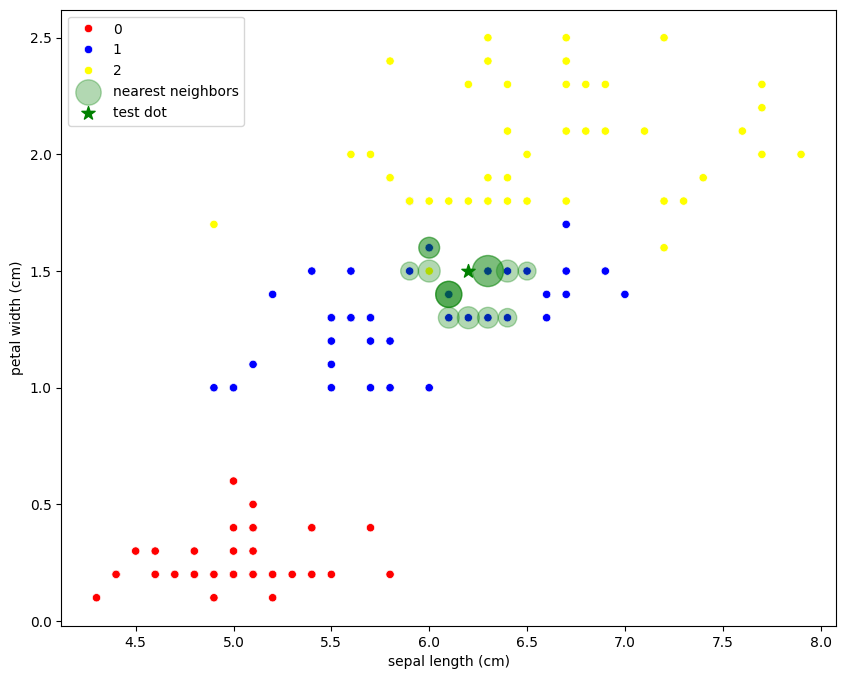

In [1427]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_bold = ['red', 'blue', 'yellow']

nearest_index = top8.index

plt.figure(figsize=(10, 8))

#обучающие данные
sns.scatterplot(
    x=X_train['sepal length (cm)'],
    y=X_train['petal width (cm)'],
    hue=y_train,
    palette=cmap_bold
)

#соседи
plt.scatter(
    X_train.iloc[nearest_index]['sepal length (cm)'],
    X_train.iloc[nearest_index]['petal width (cm)'],
    c='g',
    alpha = 0.3,
    marker='o',
    s=top8['weight']*50,
    label='nearest neighbors'
)

#тестовая точка
plt.scatter(
    X_test.iloc[test_index]['sepal length (cm)'],
    X_test.iloc[test_index]['petal width (cm)'],
    c='g',
    marker='*',
    s=100,
    label='test dot'
)

plt.legend()

## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [1428]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [1429]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [1430]:
medInc = X[['MedInc']].iloc[:1000]
y = y[:1000]
medInc

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
995,4.8624
996,9.1531
997,4.7361
998,5.4324


### Отрисуйте данные на графике

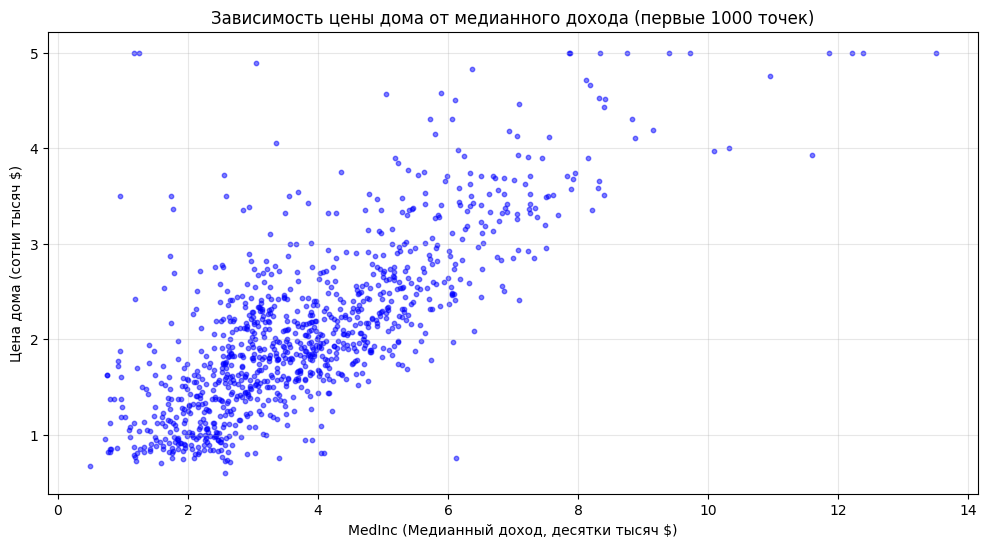

In [1431]:
import matplotlib.pyplot as plt

sort_idx = medInc['MedInc'].argsort()
medInc_sorted = medInc.iloc[sort_idx]
y_sorted = y[sort_idx]

plt.figure(figsize=(12, 6))

plt.scatter(medInc_sorted['MedInc'], y_sorted, alpha=0.5, s=10, c='blue')

plt.xlabel('MedInc (Медианный доход, десятки тысяч $)')
plt.ylabel('Цена дома (сотни тысяч $)')
plt.title('Зависимость цены дома от медианного дохода (первые 1000 точек)')
plt.grid(True, alpha=0.3)

plt.show()

### **4. KNN из sklearn**

#### 4.1. Разбейте данные на обучение и тест

In [1432]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(medInc, y, random_state=42, test_size=20)
X_train.shape, X_test.shape


((980, 1), (20, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [1433]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=n_neighbors)
model.fit(X_train, y_train)
X_train.shape, X_test.shape

((980, 1), (20, 1))

#### 4.3. Проверьте качество работы модели


In [1434]:
from sklearn.metrics import r2_score

pred_test = model.predict(X_test)
print(r2_score(y_test, pred_test))

0.7829225753913921


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [1435]:
import numpy as np
test_index = [8]
test_samples = X_test.iloc[test_index]

dist = pd.DataFrame()
dist['trained'] = y_train

samp = test_samples.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist[f'distance to test sample 8'] = distto

display(dist)


,trained,distance to test sample 8
0,2.542,1.3461
1,1.270,2.3449
2,1.306,1.4688
3,2.102,1.4375
4,1.095,1.0990
...,...,...
975,2.685,1.3419
976,2.250,0.7396
977,2.835,1.1046
978,1.875,3.1396


#### 4.5. Выберите топ  k  соседей


In [1436]:
k = 15
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k)
display(top8)


,trained,distance to test sample 8
289,2.293,0.0052
795,1.514,0.0065
29,2.353,0.0104
178,2.519,0.0104
442,2.316,0.0141
8,2.232,0.0146
139,1.962,0.0203
33,2.486,0.0204
39,1.776,0.0233
918,1.635,0.0253


#### 4.6. Выведите финальное предсказание для этого объекта

In [1437]:
pred8 = top8['trained'].mean()
print(f'predict to test sample 8 - {pred8}')

predict to test sample 8 - 2.1772


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [1438]:
print(f"Настоящее целевое значение: {y_test[test_index]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[test_index]}")


Настоящее целевое значение: [2.476]
Предсказанное целевое значение для объекта: [2.18466]


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

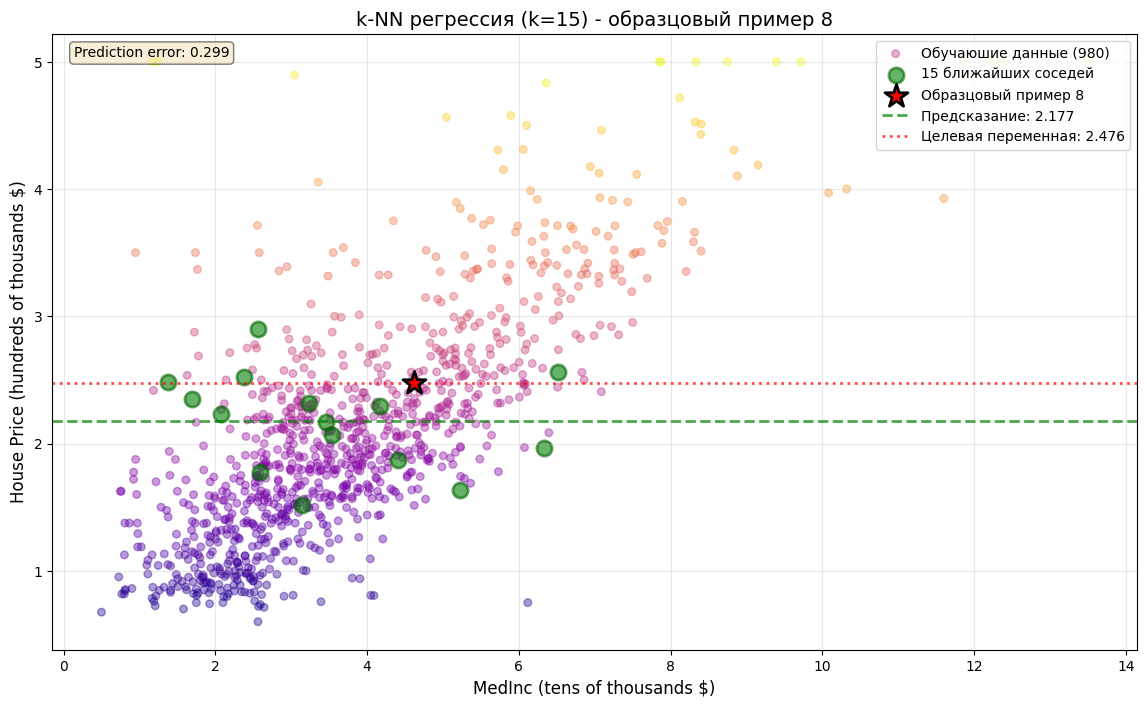

In [1439]:
import matplotlib.pyplot as plt
import numpy as np

#индексы ближайших соседей
nearest_index = top8.index

#предсказание
prediction = top8['trained'].mean()
true_value = y_test[test_index[0]]

plt.figure(figsize=(14, 8))

#обучающие данные
plt.scatter(
    X_train['MedInc'],
    y_train,
    alpha=0.4,
    s=30,
    c=y_train,
    cmap='plasma',
    label=f'Обучаюшие данные ({len(X_train)})'
)

#соседи
plt.scatter(
    X_train.loc[nearest_index, 'MedInc'],
    y_train[nearest_index],
    c='green',
    alpha=0.6,
    marker='o',
    s=120,
    edgecolors='darkgreen',
    linewidth=2,
    label=f'15 ближайших соседей'
)

#тестовая точка
plt.scatter(
    X_test.iloc[test_index[0]]['MedInc'],
    y_test[test_index[0]],
    c='red',
    marker='*',
    s=300,
    label=f'Образцовый пример {test_index[0]}',
    edgecolors='black',
    linewidth=2,
    zorder=5
)

#линии
plt.axhline(y=prediction, color='green', linestyle='--', alpha=0.7,
            linewidth=2, label=f'Предсказание: {prediction:.3f}')

plt.axhline(y=true_value, color='red', linestyle=':', alpha=0.7,
            linewidth=2, label=f'Целевая переменная: {true_value:.3f}')

plt.xlabel('MedInc (tens of thousands $)', fontsize=12)
plt.ylabel('House Price (hundreds of thousands $)', fontsize=12)
plt.title(f'k-NN регрессия (k=15) - образцовый пример {test_index[0]}', fontsize=14)

plt.text(0.02, 0.98, f'Prediction error: {abs(true_value - prediction):.3f}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [1440]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=15, weights='distance')
model.fit(X_train, y_train)
X_train.shape, X_test.shape

((980, 1), (20, 1))

#### 5.2. Проверьте качество работы модели


In [1441]:
from sklearn.metrics import r2_score

pred_test = model.predict(X_test)
print(r2_score(y_test, pred_test))


0.7085013213804798


#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [1442]:
import numpy as np
test_index = [8]
test_samples = X_test.iloc[test_index]

dist = pd.DataFrame()
dist['trained'] = y_train

samp = test_samples.values
distto = np.linalg.norm(X_train.values - samp, axis=1, ord=2)
dist[f'distance to test sample 8'] = distto

display(dist)


,trained,distance to test sample 8
0,2.542,1.3461
1,1.270,2.3449
2,1.306,1.4688
3,2.102,1.4375
4,1.095,1.0990
...,...,...
975,2.685,1.3419
976,2.250,0.7396
977,2.835,1.1046
978,1.875,3.1396


#### 5.4. Выберите топ  k  соседей


In [1443]:
k = 15
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k)
display(top8)

,trained,distance to test sample 8
289,2.293,0.0052
795,1.514,0.0065
29,2.353,0.0104
178,2.519,0.0104
442,2.316,0.0141
8,2.232,0.0146
139,1.962,0.0203
33,2.486,0.0204
39,1.776,0.0233
918,1.635,0.0253


#### 5.5. Рассчитайте вес для каждого соседа

In [1444]:
k = 15
top8 = dist.sort_values('distance to test sample 8', ascending=True).head(k).copy()

top8['weight'] = 1 / top8['distance to test sample 8']

display(top8)


,trained,distance to test sample 8,weight
289,2.293,0.0052,192.307692
795,1.514,0.0065,153.846154
29,2.353,0.0104,96.153846
178,2.519,0.0104,96.153846
442,2.316,0.0141,70.921986
8,2.232,0.0146,68.493151
139,1.962,0.0203,49.261084
33,2.486,0.0204,49.019608
39,1.776,0.0233,42.918455
918,1.635,0.0253,39.525692


#### 5.6. Выведите финальное предсказание для этого объекта

In [1445]:
weighted_prediction = (top8['trained'] * top8['weight']).sum() / top8['weight'].sum()
print(f'{weighted_prediction:.4f}')


2.1538


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [1446]:
print(f"Настоящее целевое значение: {y_test[test_index]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[test_index]}")


Настоящее целевое значение: [2.476]
Предсказанное целевое значение для объекта: [2.15383824]


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

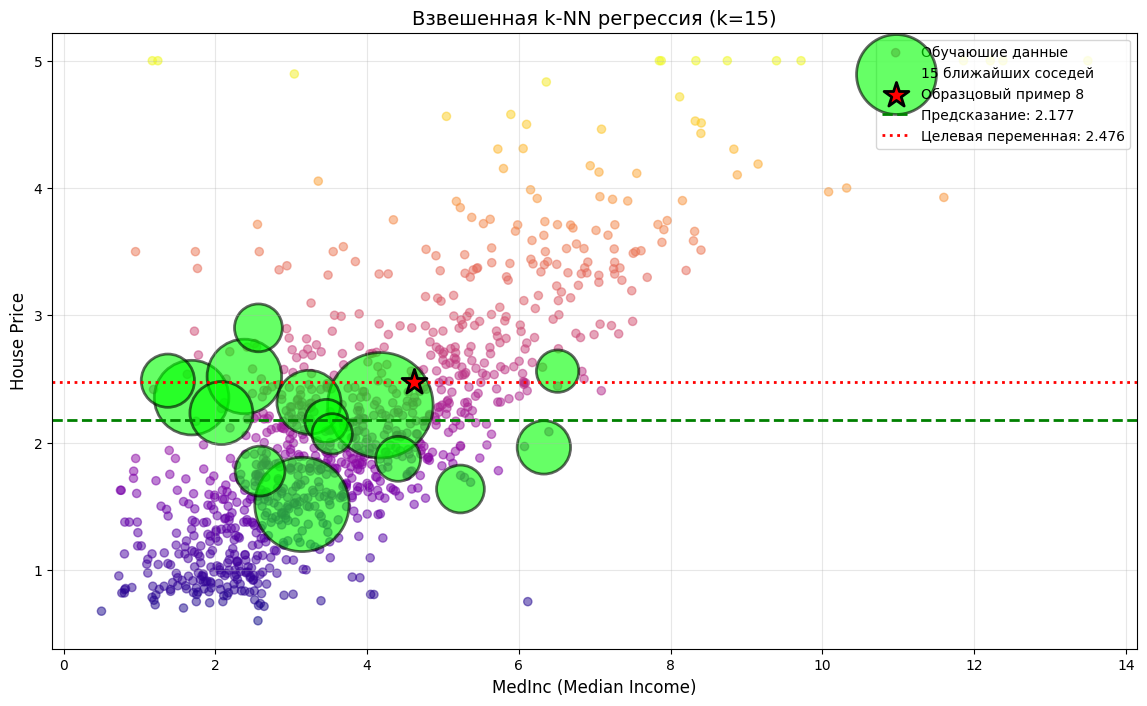

In [1447]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

#обучающие данные
scatter = plt.scatter(
    X_train['MedInc'],
    y_train,
    c=y_train,
    cmap='plasma',
    alpha=0.5,
    s=35,
    label='Обучаюшие данные'
)

#соседи
plt.scatter(
    X_train.loc[nearest_index, 'MedInc'],
    y_train[nearest_index],
    c='lime',
    alpha=0.6,
    marker='o',
    s=top8['weight'] * 30,
    edgecolors='black',
    linewidth=2,
    label=f'15 ближайших соседей'
)

#тестовая точка
plt.scatter(
    X_test.iloc[test_index[0]]['MedInc'],
    y_test[test_index[0]],
    c='red',
    marker='*',
    s=350,
    edgecolors='black',
    linewidth=2,
    zorder=5,
    label=f'Образцовый пример {test_index[0]}'
)

#линии
plt.axhline(y=prediction, color='green', linestyle='--', linewidth=2,
            label=f'Предсказание: {prediction:.3f}')
plt.axhline(y=true_value, color='red', linestyle=':', linewidth=2,
            label=f'Целевая переменная: {true_value:.3f}')

plt.xlabel('MedInc (Median Income)', fontsize=12)
plt.ylabel('House Price', fontsize=12)
plt.title(f'Взвешенная k-NN регрессия (k=15)', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [1453]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

weighted_knn = KNeighborsRegressor(weights='distance')

k_range = list(range(1, 50))
param_grid = dict(n_neighbors=k_range)

grid = GridSearchCV(weighted_knn, param_grid, cv=5, scoring='r2')
grid_search = grid.fit(X_train, y_train)

print(f"Взвешенный KNN: лучший k = {grid_search.best_params_['n_neighbors']}")
print(f"Лучший R² (взвешенный KNN): {grid_search.best_score_:.4f}")

Взвешенный KNN: лучший k = 49
Лучший R² (взвешенный KNN): 0.4836
